<a href="https://colab.research.google.com/github/Priyahiremath97/Crop_Disease_Risk_Classification.ipynb/blob/main/Crop_Disease_Risk_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Domain:** Agriculture  
**ML Task:** Classification  
**Objective:** Classify crop observations according to disease-risk categories using environmental and crop indicators.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.impute import SimpleImputer
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
      accuracy_score,
      precision_score,
      recall_score,
      f1_score,
      confusion_matrix,
      classification_report
                          )


In [9]:
df = pd.read_csv("/content/modern_agriculture_ai_crop_production_2020_2050.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 75000
Columns: 36


In [10]:
df.head()

,record_id,year,region,country,crop,farm_size_hectares,farm_type,soil_type,irrigation_type,ai_system_used,technology_stack,ai_adoption_score,mechanization_index,iot_sensor_density_per_ha,drone_usage_hours_per_month,satellite_monitoring_score,avg_temperature_c,annual_rainfall_mm,soil_moisture_percent,fertilizer_kg_per_ha,pesticide_litre_per_ha,water_use_m3_per_ha,climate_stress_index,disease_risk_score,pest_risk_score,yield_ton_per_ha,production_tons,operational_cost_usd_per_ha,market_price_usd_per_ton,revenue_usd,profit_usd,carbon_emission_kgco2e_per_ha,sustainability_score,yield_forecast_next_year_ton_per_ha,risk_category,recommended_action
0,1,2035,South America,Chile,Dates,40.78,Semi-Mechanized,Peaty,Rainfed,NaN,Robotics,22.90,59.03,2.26,7.25,62.02,34.73,885.36,23.65,104.76,1.53,499.57,32.27,30.08,57.79,8.10,330.32,1059.23,196.12,64782.36,21586.96,646.75,54.25,8.38,Moderate,Start with IoT soil sensors and basic AI analy...
1,2,2038,Middle East,Turkey,Potato,17.04,Traditional,Silty,Smart Drip,NaN,Satellite NDVI,34.00,50.05,1.27,7.60,69.82,22.06,1029.20,38.62,159.08,1.41,471.23,39.01,20.84,62.83,24.80,422.59,1017.69,442.65,187059.46,169718.02,948.05,28.77,24.56,Moderate,Start with IoT soil sensors and basic AI analy...
2,3,2036,Africa,Egypt,Mango,119.06,Smart AI Farm,Loam,Drip,AI Irrigation Agent,IoT Sensors,79.16,68.16,20.60,0.00,47.42,27.37,101.62,33.26,200.76,3.42,639.96,45.15,22.41,56.65,11.61,1382.29,1479.36,463.90,641244.33,465111.73,1062.54,57.07,11.81,Moderate,Maintain current smart farming plan
3,4,2031,Europe,Germany,Rice,23.15,Semi-Mechanized,Silty,Flood Irrigation,Yield Prediction ML,Satellite NDVI,51.47,49.14,10.05,5.23,52.58,26.56,480.55,51.49,102.68,2.72,1042.32,43.64,37.15,56.16,5.48,126.86,1088.85,375.24,47602.95,22396.07,672.48,54.67,5.60,Moderate,Shift to drip or smart irrigation
4,5,2029,South America,Colombia,Sugarcane,22.03,Semi-Mechanized,Silty,Drip,Basic Analytics,IoT Sensors,36.14,50.89,6.42,1.94,66.06,32.91,631.82,35.51,15.01,2.65,1122.11,44.58,27.56,68.39,65.43,1441.42,870.99,198.97,286799.34,267611.43,516.42,44.15,72.07,Moderate,Deploy pest monitoring traps and precision spr...


In [11]:
df.tail()

,record_id,year,region,country,crop,farm_size_hectares,farm_type,soil_type,irrigation_type,ai_system_used,technology_stack,ai_adoption_score,mechanization_index,iot_sensor_density_per_ha,drone_usage_hours_per_month,satellite_monitoring_score,avg_temperature_c,annual_rainfall_mm,soil_moisture_percent,fertilizer_kg_per_ha,pesticide_litre_per_ha,water_use_m3_per_ha,climate_stress_index,disease_risk_score,pest_risk_score,yield_ton_per_ha,production_tons,operational_cost_usd_per_ha,market_price_usd_per_ton,revenue_usd,profit_usd,carbon_emission_kgco2e_per_ha,sustainability_score,yield_forecast_next_year_ton_per_ha,risk_category,recommended_action
74995,74996,2028,East Asia,China,Tomato,7.15,Traditional,Loam,Drip,AI Irrigation Agent,Manual,71.08,29.33,12.22,0.29,19.84,24.60,589.80,42.76,171.82,3.07,358.85,53.02,22.89,28.13,38.18,272.99,1133.06,349.76,95480.98,87379.60,1021.35,73.85,38.10,Moderate,Maintain current smart farming plan
74996,74997,2050,Southeast Asia,Philippines,Mango,34.60,Smart AI Farm,Clay,Flood Irrigation,Computer Vision,GPS Mapping,49.55,40.72,11.66,2.21,39.78,29.03,875.84,44.54,48.95,2.76,919.66,34.72,41.14,63.89,9.87,341.50,978.76,803.09,274255.24,240390.14,646.29,45.46,9.85,Moderate,Maintain current smart farming plan
74997,74998,2022,North America,United States,Mango,7.88,Semi-Mechanized,Peaty,Rainfed,AI Disease Detection,Drone Monitoring,57.53,46.15,15.76,1.27,49.36,30.06,764.53,35.28,130.42,3.26,414.08,45.35,29.08,69.88,8.73,68.79,1155.21,400.01,27516.69,18413.64,708.00,60.90,8.59,Moderate,Deploy pest monitoring traps and precision spr...
74998,74999,2023,North America,United States,Dates,9.80,Greenhouse,Sandy,Sprinkler,NaN,Robotics,19.19,56.44,3.29,7.79,57.49,32.94,170.53,20.53,112.14,0.46,827.30,50.34,52.89,48.49,7.33,71.83,1010.17,194.16,13946.51,4046.84,1068.54,43.39,7.94,Moderate,Start with IoT soil sensors and basic AI analy...
74999,75000,2042,North America,Mexico,Cotton,15.21,Smart AI Farm,Loam,Flood Irrigation,Computer Vision,Drone Monitoring,61.38,55.61,13.11,0.20,40.24,25.95,382.36,44.21,214.11,1.05,593.66,36.84,19.87,35.09,2.44,37.11,1423.44,429.64,15943.94,-5706.58,1206.18,29.39,2.39,Moderate,Maintain current smart farming plan


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 36 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   record_id                            75000 non-null  int64  
 1   year                                 75000 non-null  int64  
 2   region                               75000 non-null  object 
 3   country                              75000 non-null  object 
 4   crop                                 75000 non-null  object 
 5   farm_size_hectares                   75000 non-null  float64
 6   farm_type                            75000 non-null  object 
 7   soil_type                            75000 non-null  object 
 8   irrigation_type                      75000 non-null  object 
 9   ai_system_used                       60019 non-null  object 
 10  technology_stack                     75000 non-null  object 
 11  ai_adoption_score           

In [13]:
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Shape: (75000, 36)

Column Names:
['record_id', 'year', 'region', 'country', 'crop', 'farm_size_hectares', 'farm_type', 'soil_type', 'irrigation_type', 'ai_system_used', 'technology_stack', 'ai_adoption_score', 'mechanization_index', 'iot_sensor_density_per_ha', 'drone_usage_hours_per_month', 'satellite_monitoring_score', 'avg_temperature_c', 'annual_rainfall_mm', 'soil_moisture_percent', 'fertilizer_kg_per_ha', 'pesticide_litre_per_ha', 'water_use_m3_per_ha', 'climate_stress_index', 'disease_risk_score', 'pest_risk_score', 'yield_ton_per_ha', 'production_tons', 'operational_cost_usd_per_ha', 'market_price_usd_per_ton', 'revenue_usd', 'profit_usd', 'carbon_emission_kgco2e_per_ha', 'sustainability_score', 'yield_forecast_next_year_ton_per_ha', 'risk_category', 'recommended_action']


In [14]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print("Columns containing missing values:")
print(missing)

Columns containing missing values:
ai_system_used    14981
dtype: int64


In [15]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [16]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (75000, 36)


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
record_id,75000.0,37500.500000,21650.779432,1.00,18750.7500,37500.500,56250.2500,75000.00
year,75000.0,2034.956960,8.927437,2020.00,2027.0000,2035.000,2043.0000,2050.00
farm_size_hectares,75000.0,26.904183,17.763317,0.64,13.7975,23.100,35.8300,193.60
ai_adoption_score,75000.0,52.687583,20.301630,0.00,36.7300,51.780,68.1800,100.00
mechanization_index,75000.0,50.005910,16.480170,0.00,38.2075,49.535,61.4300,100.00
iot_sensor_density_per_ha,75000.0,7.879769,5.201213,0.00,3.7100,6.820,11.0700,27.97
drone_usage_hours_per_month,75000.0,4.088757,4.101138,0.00,0.7800,2.840,6.2300,20.84
satellite_monitoring_score,75000.0,48.573390,23.954710,0.00,30.2000,47.230,66.2100,100.00
avg_temperature_c,75000.0,27.003973,5.503631,7.67,23.1400,26.970,30.7600,46.92
annual_rainfall_mm,75000.0,651.015669,275.632315,50.00,460.9400,648.140,836.0000,1906.85


In [18]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['region', 'country', 'crop', 'farm_type', 'soil_type', 'irrigation_type', 'ai_system_used', 'technology_stack', 'risk_category', 'recommended_action']


In [19]:
bins = [-np.inf, 25, 40, 55, np.inf]

labels = [
    "Low",
    "Moderate",
    "High",
    "Critical"
                ]

df["disease_risk_category"] = pd.cut(
    df["disease_risk_score"],
    bins=bins,
    labels=labels
                            )

In [20]:
df["disease_risk_category"].value_counts().sort_index()

,count
disease_risk_category,
Low,20114
Moderate,37524
High,15878
Critical,1484


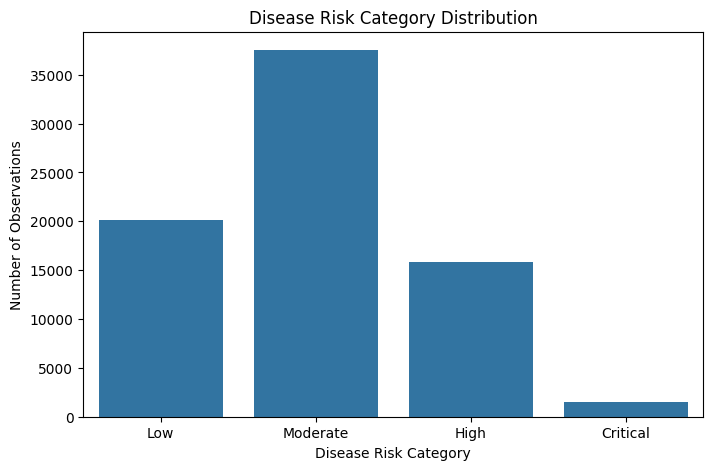

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(
      data=df,
      x="disease_risk_category",
      order=["Low", "Moderate", "High", "Critical"]
              )
plt.title("Disease Risk Category Distribution")
plt.xlabel("Disease Risk Category")
plt.ylabel("Number of Observations")

plt.show()

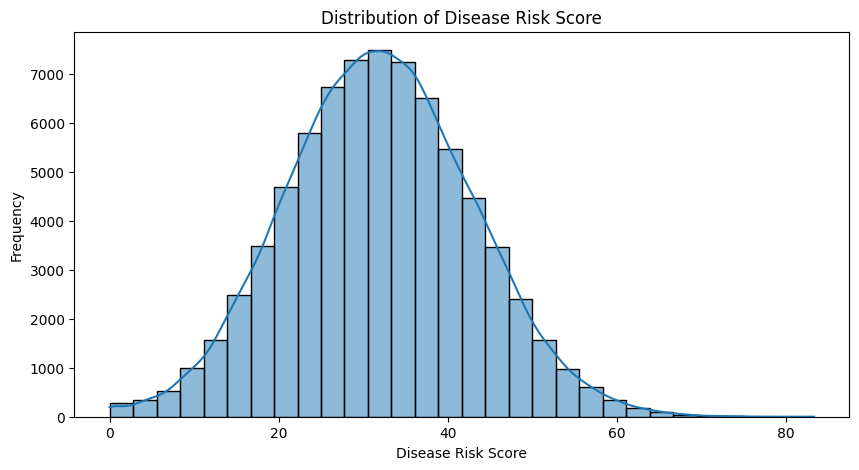

In [22]:
plt.figure(figsize=(10,5))
sns.histplot(
      df["disease_risk_score"],
       bins=30,
       kde=True
              )
plt.title("Distribution of Disease Risk Score")
plt.xlabel("Disease Risk Score")
plt.ylabel("Frequency")

plt.show()

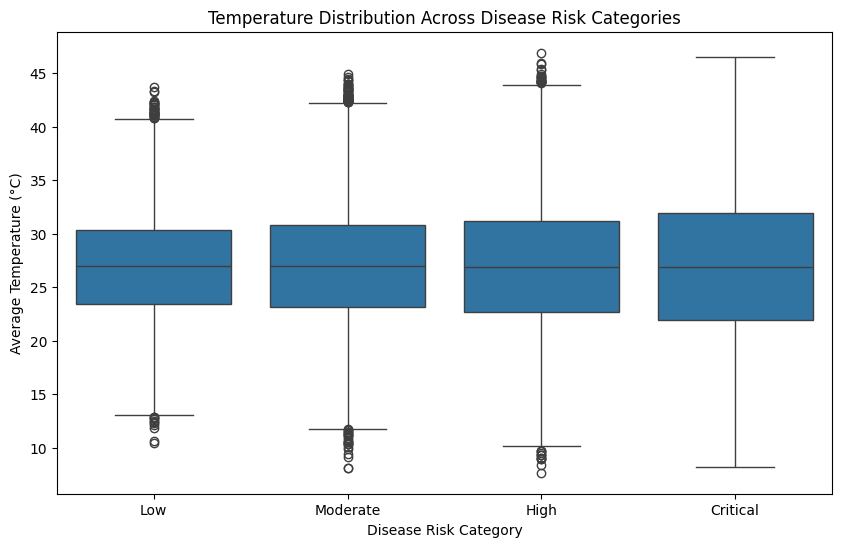

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(
      data=df,
      x="disease_risk_category",
      y="avg_temperature_c",
      order=["Low", "Moderate", "High", "Critical"]
                  )
plt.title("Temperature Distribution Across Disease Risk Categories")
plt.xlabel("Disease Risk Category")
plt.ylabel("Average Temperature (°C)")

plt.show()


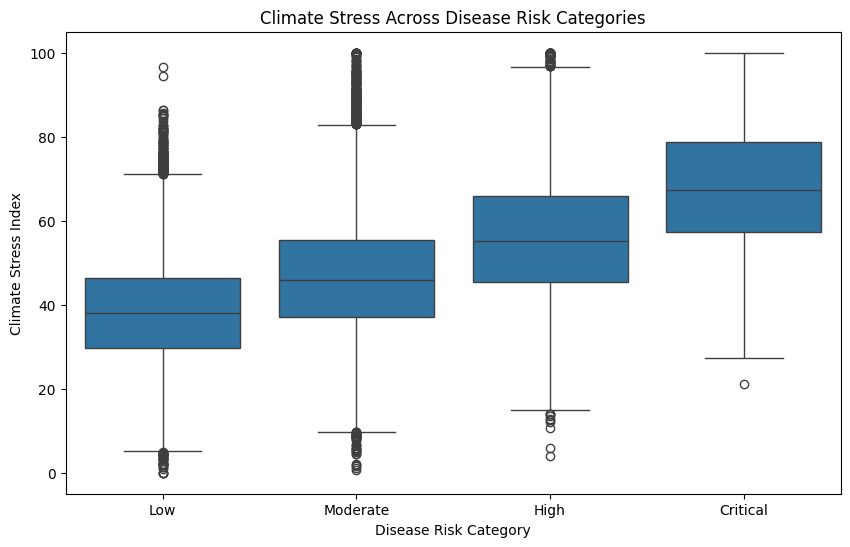

In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(
      data=df,
      x="disease_risk_category",
      y="climate_stress_index",
      order=["Low", "Moderate", "High", "Critical"]
                  )
plt.title("Climate Stress Across Disease Risk Categories")
plt.xlabel("Disease Risk Category")
plt.ylabel("Climate Stress Index")

plt.show()

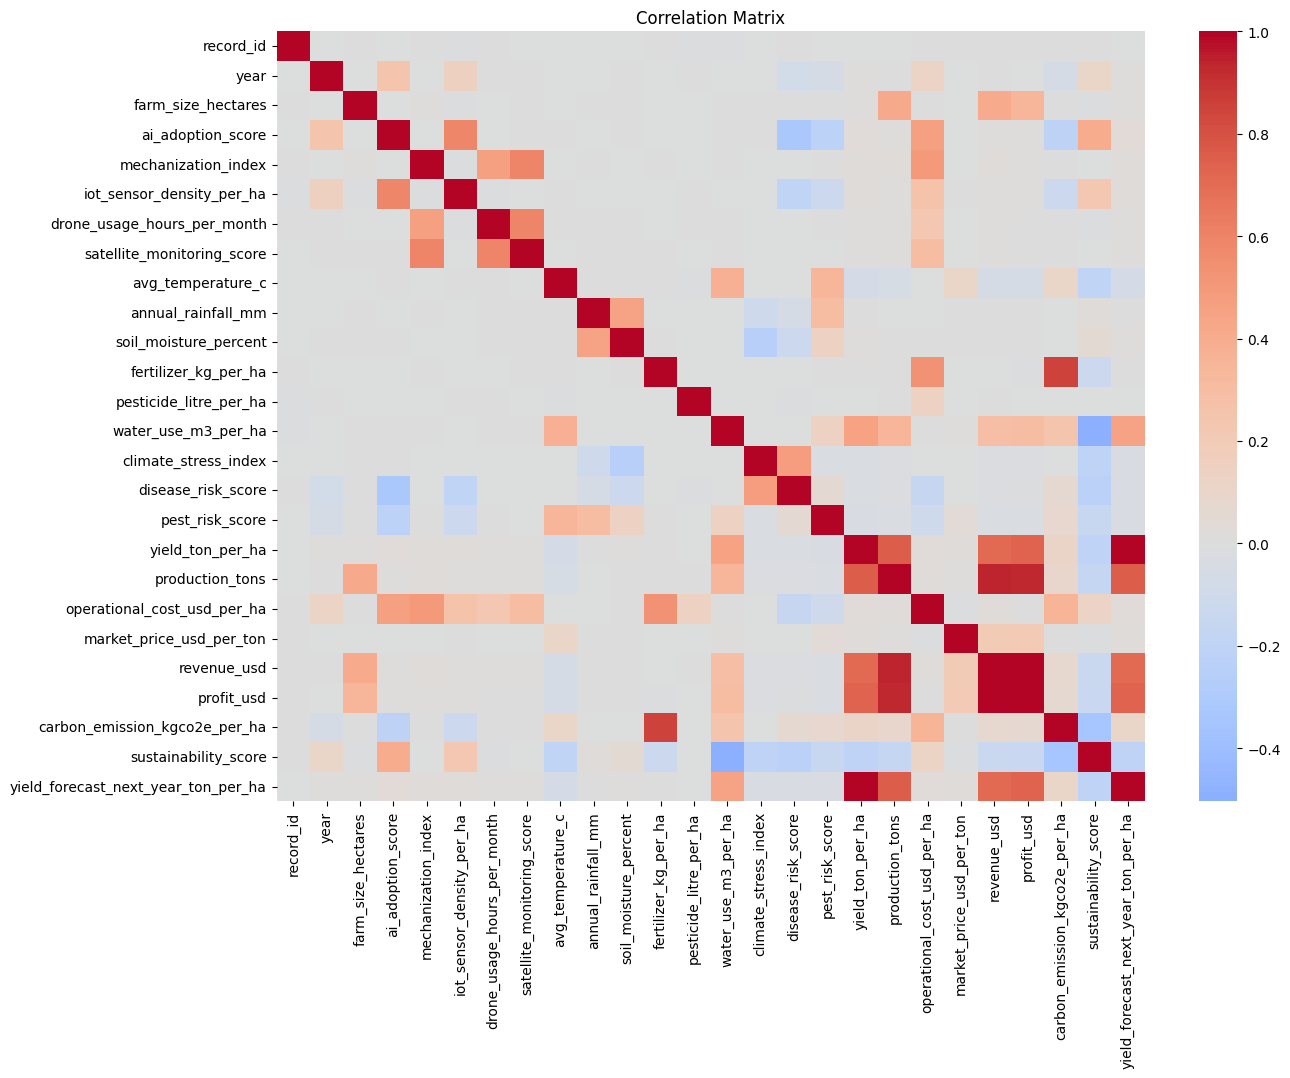

In [25]:
numeric_columns = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(14,10))

correlation = df[numeric_columns].corr()
sns.heatmap(
      correlation,
      cmap="coolwarm",
      center=0
              )
plt.title("Correlation Matrix")

plt.show()

In [26]:
correlation_with_disease = (
      df[numeric_columns]
      .corr()["disease_risk_score"]
      .sort_values(ascending=False)
              )

print(correlation_with_disease)


disease_risk_score                     1.000000
climate_stress_index                   0.479400
carbon_emission_kgco2e_per_ha          0.068869
pest_risk_score                        0.055676
farm_size_hectares                     0.005354
record_id                              0.001557
market_price_usd_per_ton               0.000231
water_use_m3_per_ha                   -0.001060
drone_usage_hours_per_month           -0.001948
satellite_monitoring_score            -0.003429
fertilizer_kg_per_ha                  -0.003589
mechanization_index                   -0.003633
avg_temperature_c                     -0.004318
pesticide_litre_per_ha                -0.004991
profit_usd                            -0.014581
revenue_usd                           -0.016488
production_tons                       -0.018776
yield_ton_per_ha                      -0.027665
yield_forecast_next_year_ton_per_ha   -0.030161
annual_rainfall_mm                    -0.054585
year                                  -0

In [27]:
features = [
    "avg_temperature_c",
     "annual_rainfall_mm",
     "soil_moisture_percent",
     "fertilizer_kg_per_ha",
     "pesticide_litre_per_ha",
     "water_use_m3_per_ha",
     "climate_stress_index",
     "crop",
     "soil_type",
     "irrigation_type",
     "farm_type"
]
X = df[features]

y = df["disease_risk_category"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['avg_temperature_c', 'annual_rainfall_mm', 'soil_moisture_percent', 'fertilizer_kg_per_ha', 'pesticide_litre_per_ha', 'water_use_m3_per_ha', 'climate_stress_index', 'crop', 'soil_type', 'irrigation_type', 'farm_type']

Target:
disease_risk_category


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
      X,
      y,
      test_size=0.20,
      random_state=42,
      stratify=y
                      )

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 60000
Testing samples: 15000


In [29]:
numeric_features = [
      "avg_temperature_c",
      "annual_rainfall_mm",
      "soil_moisture_percent",
      "fertilizer_kg_per_ha",
      "pesticide_litre_per_ha",
      "water_use_m3_per_ha",
      "climate_stress_index"
                              ]

categorical_features = [
                        "crop",
                        "soil_type",
                        "irrigation_type",
                        "farm_type"
                                              ]


In [48]:
numeric_transformer = Pipeline(
      steps=[
              ("imputer", SimpleImputer(strategy="median")),
              ("scaler", StandardScaler())
                          ]
                          )

categorical_transformer = Pipeline(
          steps=[
               ("imputer", SimpleImputer(strategy="most_frequent")),
               ("encoder", OneHotEncoder(handle_unknown="ignore"))
                                                  ]
                                                  )

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
                                                                          ]
                                                                          )


In [49]:
logistic_model = Pipeline(
      steps=[
         ("preprocessor", preprocessor),
        ("model", LogisticRegression(
              max_iter=1000,
              class_weight="balanced"
        ))
                                                          ]
                                                          )

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)


In [50]:
knn_model = Pipeline(
      steps=[
              ("preprocessor", preprocessor),
              ("model", KNeighborsClassifier(n_neighbors=5))
                          ]
                          )

knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)


In [51]:
tree_model = Pipeline(
      steps=[
            ("preprocessor", preprocessor),
            ("model", DecisionTreeClassifier(
                      random_state=42,
                      class_weight="balanced",
                      max_depth=10
                ))
                                                                      ]
                                                                      )

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)


In [64]:
print("Logistic Regression")
print("Accuracy :", round(accuracy_score(y_test, logistic_predictions), 4))
print("Precision:", round(precision_score(y_test, logistic_predictions, average="weighted", zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, logistic_predictions, average="weighted", zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, logistic_predictions, average="weighted", zero_division=0), 4))

Logistic Regression
Accuracy : 0.37
Precision: 0.4527
Recall   : 0.37
F1 Score : 0.3737


In [65]:
print("KNN")
print("Accuracy :", round(accuracy_score(y_test, knn_predictions), 4))
print("Precision:", round(precision_score(y_test, knn_predictions, average="weighted", zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, knn_predictions, average="weighted", zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, knn_predictions, average="weighted", zero_division=0), 4))

KNN
Accuracy : 0.4267
Precision: 0.4169
Recall   : 0.4267
F1 Score : 0.421


In [66]:
print("Decision Tree")
print("Accuracy :", round(accuracy_score(y_test, tree_predictions), 4))
print("Precision:", round(precision_score(y_test, tree_predictions, average="weighted", zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, tree_predictions, average="weighted", zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, tree_predictions, average="weighted", zero_division=0), 4))

Decision Tree
Accuracy : 0.3833
Precision: 0.4522
Recall   : 0.3833
F1 Score : 0.394


In [62]:
results = []
results.append(evaluate_model("Logistic Regression", y_test, logistic_predictions))
results.append(evaluate_model("KNN", y_test, knn_predictions))
results.append(evaluate_model("Decision Tree", y_test, tree_predictions))

results_df = pd.DataFrame(results)

results_df

,0
0,None
1,None
2,None


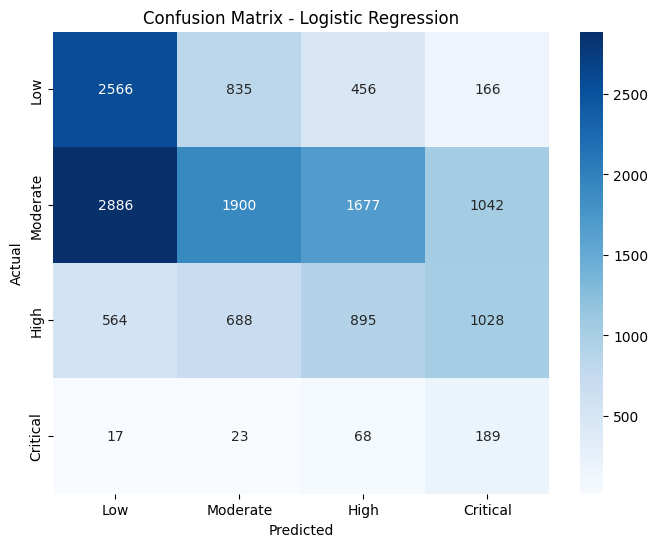

In [71]:
cm = confusion_matrix(
      y_test,
      logistic_predictions,
      labels=["Low", "Moderate", "High", "Critical"]
              )
plt.figure(figsize=(8,6))

sns.heatmap(cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Moderate", "High", "Critical"],
    yticklabels=["Low", "Moderate", "High", "Critical"]
                    )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [74]:
final_model = tree_model
joblib.dump(
      final_model,
      "crop_disease_risk_model.pkl"
          )

print("Final model saved successfully.")


Final model saved successfully.
